# Electricity Demand Forecasting Using XGBoost & Time-Series Feature Engineering

In [1]:
# Install & import all required libraries
import subprocess, sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load the dataset

In [4]:
# Load the UCI dataset 
from ucimlrepo import fetch_ucirepo

print("Fetching dataset from UCI Repository (this may take ~30–60 seconds)...")
dataset = fetch_ucirepo(id=235)

# Combine features into a single DataFrame
df_raw = dataset.data.features.copy()

print(f"Dataset loaded successfully!")
print(f"Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Fetching dataset from UCI Repository (this may take ~30–60 seconds)...
Dataset loaded successfully!
Shape : 2,075,259 rows × 9 columns
Memory : 925.5 MB


In [5]:
# raw data
print("FIRST 5 ROWS")
display(df_raw.head())

print("COLUMN DATA TYPES")
print(df_raw.dtypes)


FIRST 5 ROWS


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


COLUMN DATA TYPES
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


In [6]:
# Dataset summary statistics
print("DESCRIPTIVE STATISTICS")
display(df_raw.describe().round(4))

DESCRIPTIVE STATISTICS


,Sub_metering_3
count,2.049280e+06
mean,6.458400e+00
std,8.437200e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [7]:
# Missing value audit
missing = df_raw.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Count": missing,
})
print("MISSING VALUES REPORT")
if missing_df.empty:
    print("No missing values found in raw data.")
else:
    display(missing_df)
    print(f"\nTotal missing values: {missing.sum():,}")


MISSING VALUES REPORT


,Missing Count
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979



Total missing values: 25,979


# Step 2: Data Preprocessing & Cleaning


In [44]:
# Parse DateTime & set as index
df = df_raw.copy()

# Combine Date + Time into a single datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Drop original Date and Time columns
df.drop(columns=["Date", "Time"], inplace=True)

# Set Datetime as index
df.set_index("Datetime", inplace=True)
df.sort_index(inplace=True)

print("DateTime parsed and set as index")
print(f"Date range : {df.index.min()} -> {df.index.max()}")
print(f"Total span : {(df.index.max() - df.index.min()).days} days")
print(f"Frequency  : 1-minute intervals")
print()
display(df.head(3))

DateTime parsed and set as index
Date range : 2006-12-16 17:24:00 -> 2010-11-26 21:02:00
Total span : 1441 days
Frequency  : 1-minute intervals



,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0


In [45]:
# Ensure correct numeric data types
numeric_cols = [
    "Global_active_power", "Global_reactive_power",
    "Voltage", "Global_intensity",
    "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")   # '?' -> NaN

print("All columns converted to float64")
print()
print(df.dtypes)

All columns converted to float64

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [46]:
# Handle missing values
print(f"Missing values BEFORE cleaning: {df.isnull().sum().sum():,}")

# Forward-fill short gaps (<= 60 minutes = 60 rows at 1-min frequency)
df.ffill(limit=60, inplace=True)

# Drop any remaining rows that still have NaN (long outages etc.)
rows_before = len(df)
df.dropna(inplace=True)
rows_after  = len(df)

print(f"Missing values AFTER  cleaning: {df.isnull().sum().sum():,}")
print(f"Rows removed   : {rows_before - rows_after:,}")
print(f"Rows remaining : {rows_after:,}")

Missing values BEFORE cleaning: 181,853
Missing values AFTER  cleaning: 0
Rows removed   : 25,151
Rows remaining : 2,050,108


In [47]:
# Outlier capping using IQR method (on target column)
target = "Global_active_power"

Q1  = df[target].quantile(0.01)
Q99 = df[target].quantile(0.99)

outliers_count = ((df[target] < Q1) | (df[target] > Q99)).sum()

# Cap (clip) rather than drop - preserves time continuity
df[target] = df[target].clip(lower=Q1, upper=Q99)

print(f"Outlier capping complete on '{target}'")
print(f"1st  percentile (floor) : {Q1:.4f} kW")
print(f"99th percentile (cap)   : {Q99:.4f} kW")
print(f"Values capped           : {outliers_count:,}")

# Also clip voltage to physically valid range
df["Voltage"] = df["Voltage"].clip(lower=200, upper=260)
print("Voltage clipped to [200, 260] V")

Outlier capping complete on 'Global_active_power'
1st  percentile (floor) : 0.1100 kW
99th percentile (cap)   : 4.8500 kW
Values capped           : 39,393
Voltage clipped to [200, 260] V


In [48]:
# Resample from 1-minute -> Hourly averages
df_hourly = df.resample("h").mean().round(4)

# Drop any NaN rows that arise from empty hours after resampling
df_hourly.dropna(inplace=True)

print("Resampled to hourly frequency")
print(f"Original rows : {len(df):,} (1-minute)")
print(f"Hourly rows   : {len(df_hourly):,} (1-hour)")
print(f"Compression   : {len(df)/len(df_hourly):.1f}x")
print()
display(df_hourly.head())

Resampled to hourly frequency
Original rows : 2,050,108 (1-minute)
Hourly rows   : 34,176 (1-hour)
Compression   : 60.0x



,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,3.9638,0.2290,234.6439,18.1000,0.0,0.5278,16.8611
2006-12-16 18:00:00,3.5065,0.0800,234.5802,15.6000,0.0,6.7167,16.8667
2006-12-16 19:00:00,3.4002,0.0852,233.2325,14.5033,0.0,1.4333,16.6833
2006-12-16 20:00:00,3.2686,0.0751,234.0715,13.9167,0.0,0.0000,16.7833
2006-12-16 21:00:00,3.0565,0.0767,237.1587,13.0467,0.0,0.4167,17.2167


In [49]:
# Add calendar / time-based features
df_hourly["hour"]         = df_hourly.index.hour
df_hourly["day_of_week"]  = df_hourly.index.dayofweek        # 0=Mon, 6=Sun
df_hourly["day_of_month"] = df_hourly.index.day
df_hourly["month"]        = df_hourly.index.month
df_hourly["quarter"]      = df_hourly.index.quarter
df_hourly["year"]         = df_hourly.index.year
df_hourly["week_of_year"] = df_hourly.index.isocalendar().week.astype(int)
df_hourly["is_weekend"]   = (df_hourly.index.dayofweek >= 5).astype(int)

# Season encoding (Northern hemisphere: France)
def get_season(month):
    if month in [12, 1, 2]:   return 0   # Winter
    elif month in [3, 4, 5]:  return 1   # Spring
    elif month in [6, 7, 8]:  return 2   # Summer
    else:                      return 3   # Autumn

df_hourly["season"] = df_hourly["month"].apply(get_season)

print("Calendar features added:")
new_features = ["hour","day_of_week","day_of_month","month",
                "quarter","year","week_of_year","is_weekend","season"]
for f in new_features:
    print(f"   + {f}")

Calendar features added:
   + hour
   + day_of_week
   + day_of_month
   + month
   + quarter
   + year
   + week_of_year
   + is_weekend
   + season


In [50]:
# Final preprocessed dataset overview
print("PREPROCESSING COMPLETE - FINAL DATASET SUMMARY")
print(f"Shape         : {df_hourly.shape[0]:,} rows x {df_hourly.shape[1]} columns")
print(f"Date range    : {df_hourly.index.min().date()}  ->  {df_hourly.index.max().date()}")
print(f"Missing values: {df_hourly.isnull().sum().sum()}")
print(f"Memory usage  : {df_hourly.memory_usage(deep=True).sum()/1e6:.2f} MB")
print()
display(df_hourly.describe().round(3))

PREPROCESSING COMPLETE - FINAL DATASET SUMMARY
Shape         : 34,176 rows x 16 columns
Date range    : 2006-12-16  ->  2010-11-26
Missing values: 0
Memory usage  : 3.83 MB



,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,season
count,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000,34176.000
mean,1.083,0.124,240.840,4.628,1.121,1.298,6.458,11.504,2.990,15.713,6.455,2.490,2008.425,26.306,0.283,1.513
std,0.871,0.067,3.001,3.758,3.538,4.192,7.351,6.926,1.998,8.801,3.423,1.114,1.125,14.978,0.450,1.110
min,0.140,0.000,225.834,0.503,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,2006.000,1.000,0.000,0.000
25%,0.342,0.078,239.181,1.513,0.000,0.000,0.650,5.000,1.000,8.000,3.000,1.000,2007.000,13.000,0.000,1.000
50%,0.802,0.107,240.978,3.422,0.000,0.333,1.650,12.000,3.000,16.000,6.000,2.000,2008.000,26.000,0.000,2.000
75%,1.578,0.149,242.695,6.607,0.000,0.650,14.217,18.000,5.000,23.000,9.000,3.000,2009.000,39.000,1.000,3.000
max,4.843,0.774,251.902,28.383,48.367,46.433,21.550,23.000,6.000,31.000,12.000,4.000,2010.000,53.000,1.000,3.000


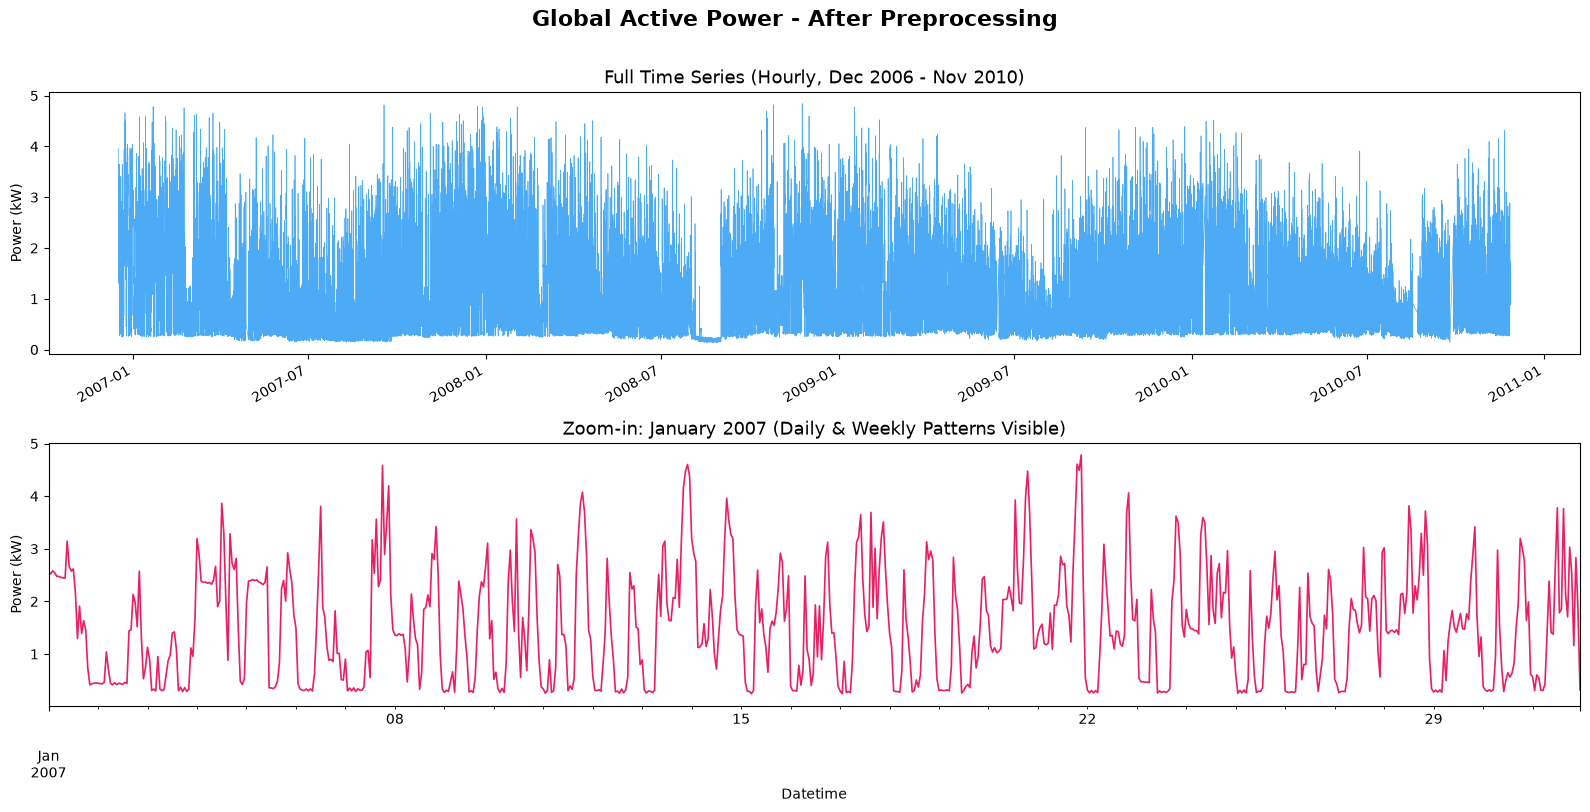

Plot saved as step2_sanity_check.png


In [51]:
# Quick sanity-check plot
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle("Global Active Power - After Preprocessing", fontsize=16, fontweight="bold", y=1.01)

# Full series
ax1 = axes[0]
df_hourly["Global_active_power"].plot(ax=ax1, color="#2196F3", linewidth=0.5, alpha=0.8)
ax1.set_title("Full Time Series (Hourly, Dec 2006 - Nov 2010)", fontsize=13)
ax1.set_ylabel("Power (kW)")
ax1.set_xlabel("")

# One month zoom (Jan 2007)
ax2 = axes[1]
zoom = df_hourly["2007-01":"2007-01"]["Global_active_power"]
zoom.plot(ax=ax2, color="#E91E63", linewidth=1.2)
ax2.set_title("Zoom-in: January 2007 (Daily & Weekly Patterns Visible)", fontsize=13)
ax2.set_ylabel("Power (kW)")
ax2.set_xlabel("Datetime")

plt.tight_layout()
plt.savefig("step2_sanity_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as step2_sanity_check.png")

In [52]:
# Save preprocessed data as checkpoint
df_hourly.to_csv("electricity_preprocessed.csv")
print("Preprocessed dataset saved -> electricity_preprocessed.csv")

Preprocessed dataset saved -> electricity_preprocessed.csv


# Step 3: Exploratory Data Analysis (EDA)


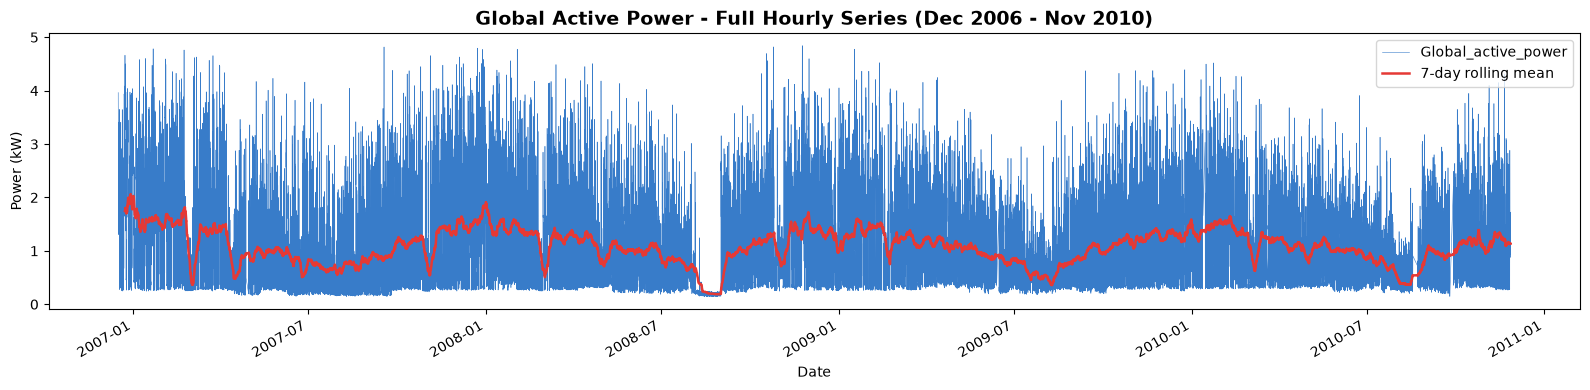

Observation: Clear seasonal cycles - higher consumption in winter months.


In [53]:
# 3.1 Full time-series overview
# FIX: Use df_hourly (not df which is 1-min data) for consistency with preprocessed data
fig, ax = plt.subplots(figsize=(16, 4))
df_hourly["Global_active_power"].plot(ax=ax, color="#1565C0", lw=0.4, alpha=0.85)

# Overlay 7-day rolling mean
df_hourly["Global_active_power"].rolling(24*7).mean().plot(
    ax=ax, color="#E53935", lw=1.8, label="7-day rolling mean")

ax.set_title("Global Active Power - Full Hourly Series (Dec 2006 - Nov 2010)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Power (kW)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("eda_full_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: Clear seasonal cycles - higher consumption in winter months.")

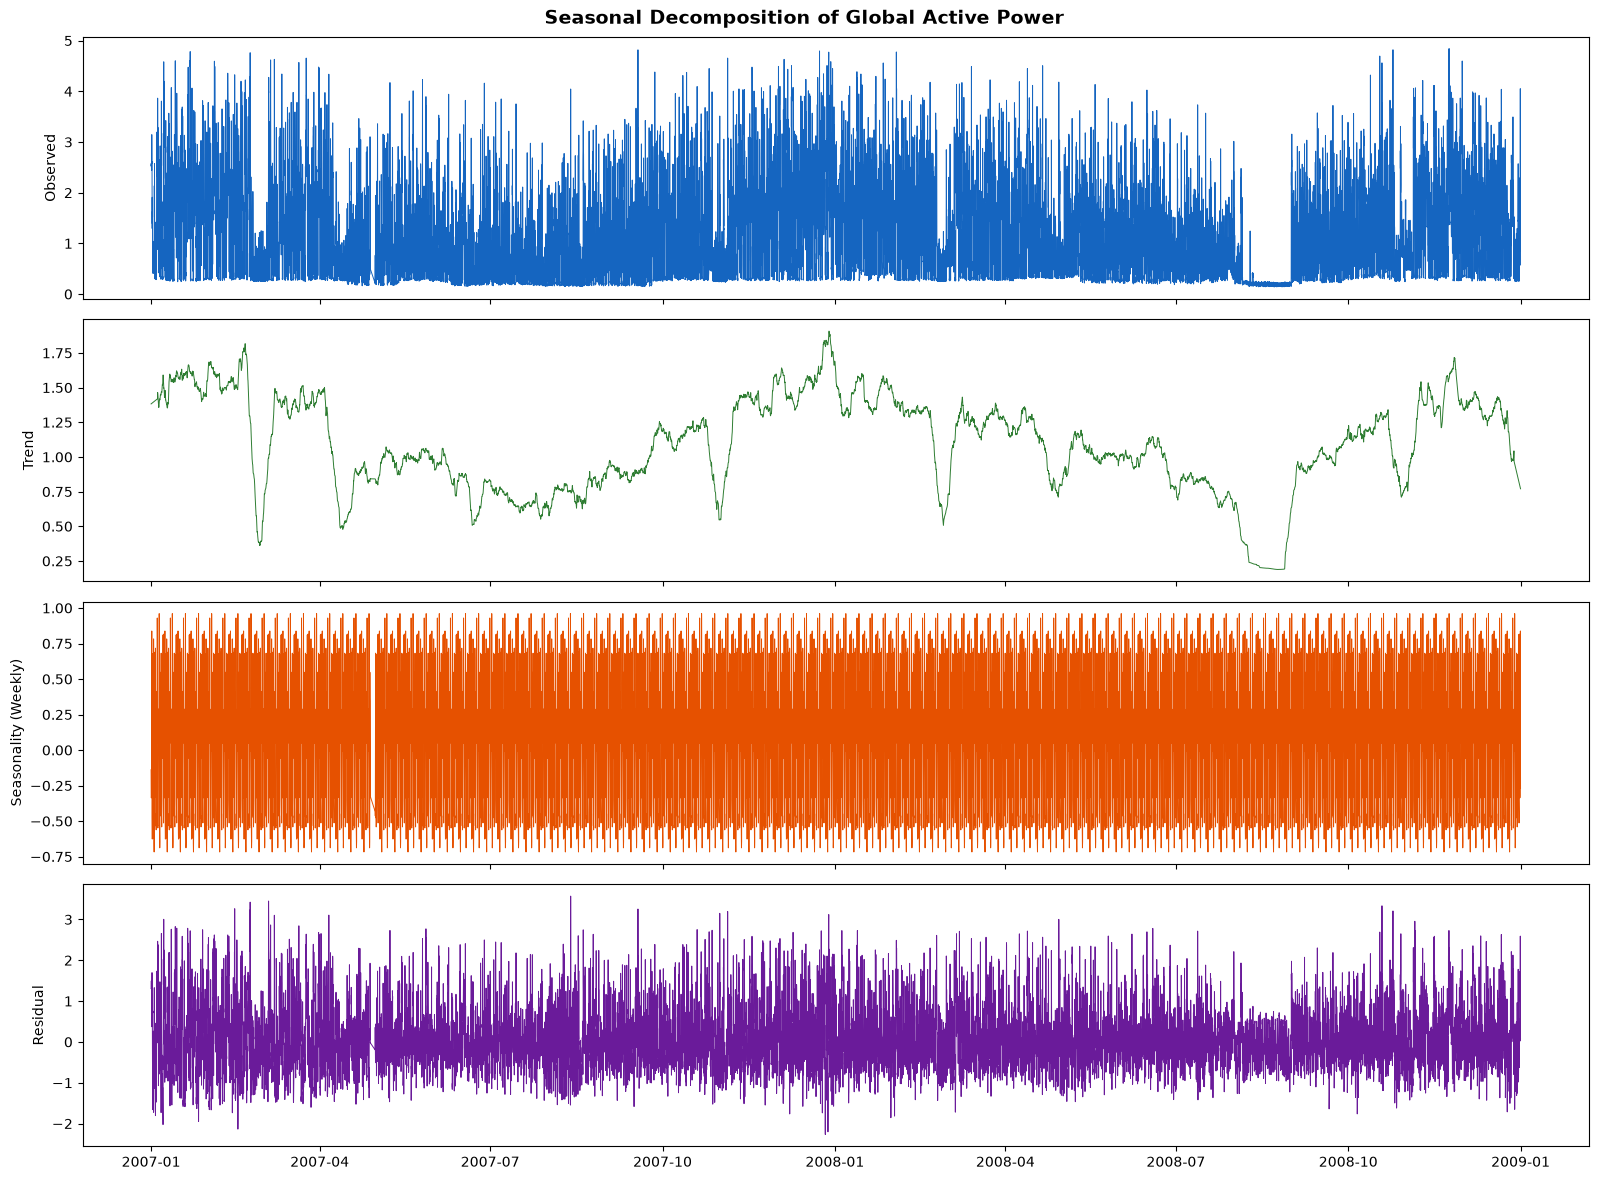

Observation: Strong upward trend in winter + clear weekly seasonality.


In [54]:
# 3.2 Seasonal decomposition (weekly seasonality, period = 24x7 hours)
# FIX: Use df_hourly instead of df (1-min data has wrong period for hourly decomposition)
sample = df_hourly["Global_active_power"]["2007-01":"2008-12"]   # 2 yrs for speed

decomp = seasonal_decompose(sample, model="additive", period=24*7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Seasonal Decomposition of Global Active Power", fontsize=14, fontweight="bold")

for ax, data, title, color in zip(
        axes,
        [sample, decomp.trend, decomp.seasonal, decomp.resid],
        ["Observed", "Trend", "Seasonality (Weekly)", "Residual"],
        ["#1565C0","#2E7D32","#E65100","#6A1B9A"]):
    ax.plot(data, color=color, lw=0.7)
    ax.set_ylabel(title, fontsize=10)

plt.tight_layout()
plt.savefig("eda_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: Strong upward trend in winter + clear weekly seasonality.")

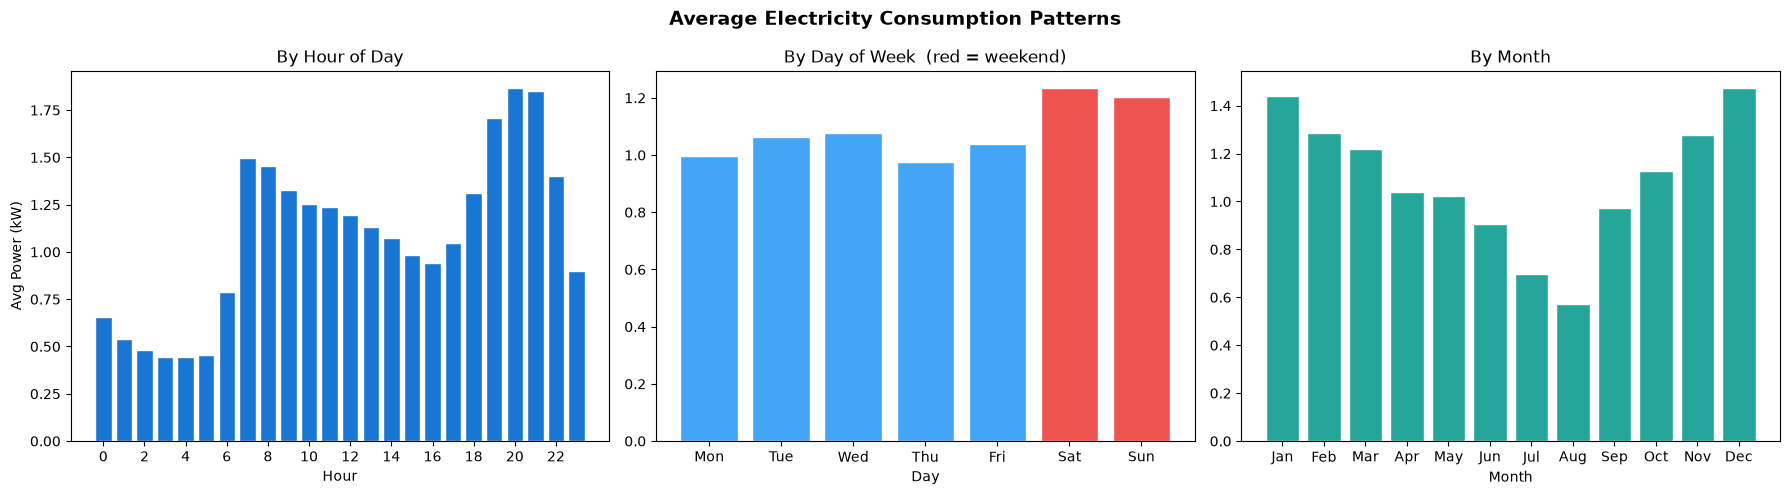

Observations:
   * Peak usage: Evening hours (18:00-21:00) and early morning (07:00-09:00)
   * Weekends slightly higher than weekdays
   * Winter months (Dec-Feb) consume ~2x more than summer


In [55]:
# 3.3 Consumption patterns by Hour, Weekday and Month
# FIX: Use df_hourly which already has hour/day_of_week/month columns added in Step 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Average Electricity Consumption Patterns", fontsize=14, fontweight="bold")

# Hour of day
hourly_avg = df_hourly.groupby("hour")["Global_active_power"].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color="#1976D2", edgecolor="white")
axes[0].set_title("By Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Power (kW)")
axes[0].set_xticks(range(0, 24, 2))

# Day of week
day_avg  = df_hourly.groupby("day_of_week")["Global_active_power"].mean()
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
colors_d = ["#42A5F5"]*5 + ["#EF5350"]*2
axes[1].bar(day_labels, day_avg.values, color=colors_d, edgecolor="white")
axes[1].set_title("By Day of Week  (red = weekend)")
axes[1].set_xlabel("Day")

# Month
month_avg   = df_hourly.groupby("month")["Global_active_power"].mean()
month_labels= ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[2].bar(month_labels, month_avg.values, color="#26A69A", edgecolor="white")
axes[2].set_title("By Month")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.savefig("eda_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observations:")
print("   * Peak usage: Evening hours (18:00-21:00) and early morning (07:00-09:00)")
print("   * Weekends slightly higher than weekdays")
print("   * Winter months (Dec-Feb) consume ~2x more than summer")

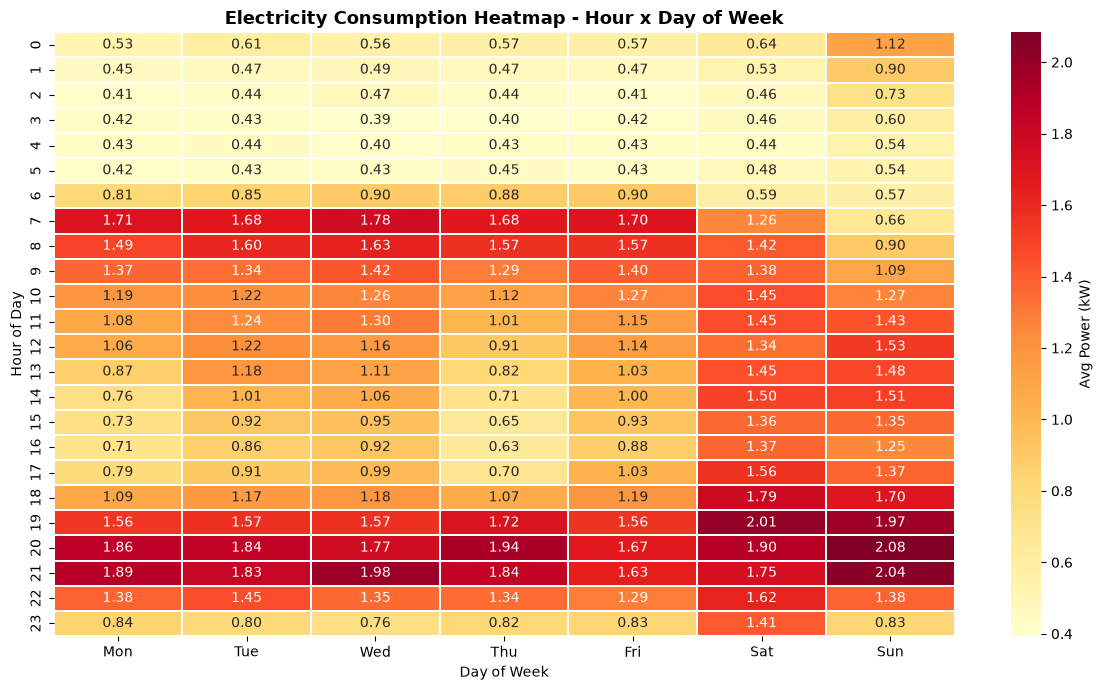

Hotspots: Weekend evenings + weekday mornings show highest consumption.


In [56]:
# 3.4 Heatmap - Average power by Hour x Weekday
pivot = df_hourly.pivot_table(
    values="Global_active_power",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)
pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, annot=True,
            fmt=".2f", ax=ax, cbar_kws={"label": "Avg Power (kW)"})
ax.set_title("Electricity Consumption Heatmap - Hour x Day of Week",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("eda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Hotspots: Weekend evenings + weekday mornings show highest consumption.")

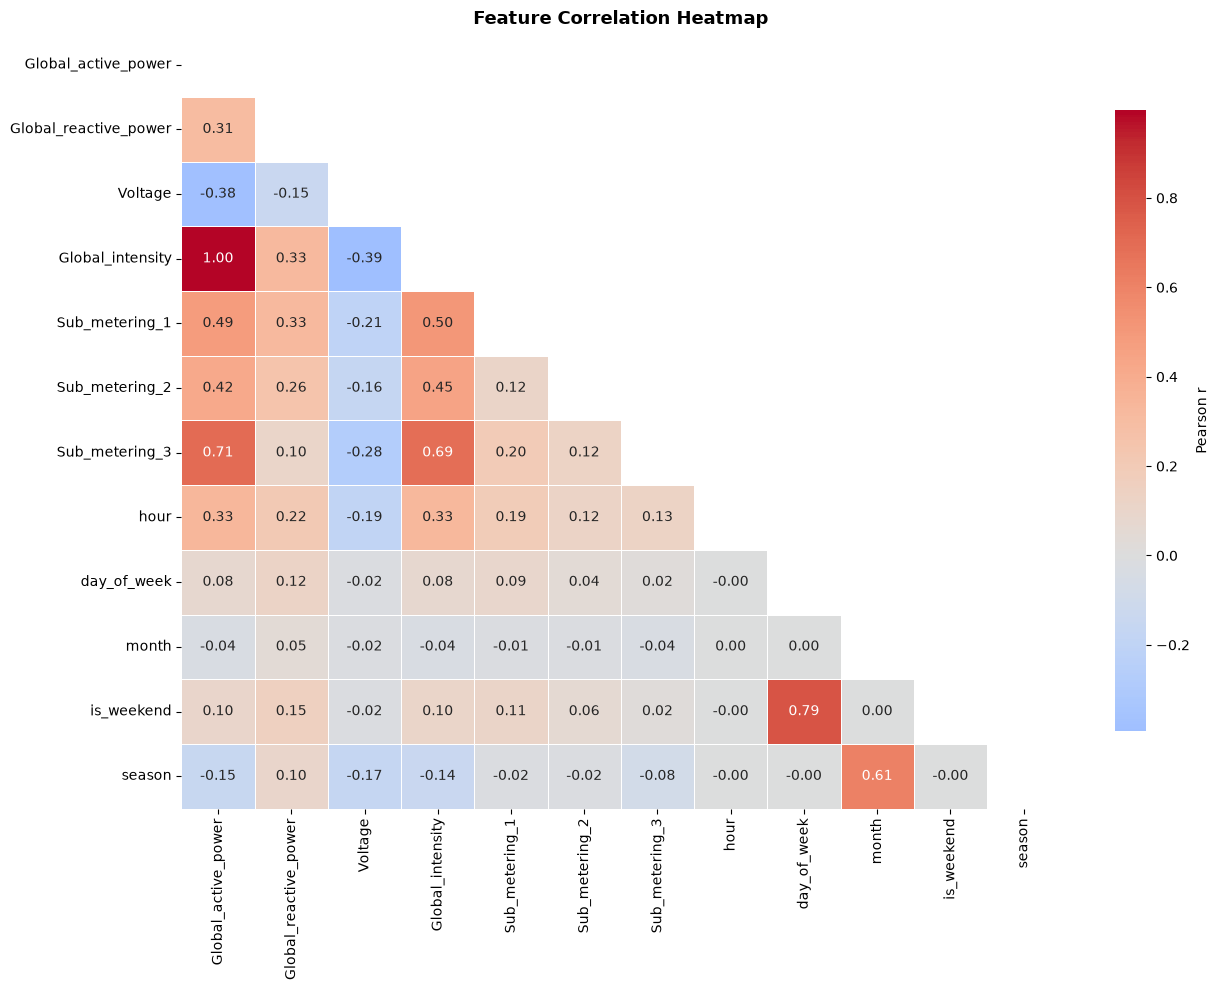


Top correlations with Global_active_power:
Global_intensity         0.997
Sub_metering_3           0.706
Sub_metering_1           0.486
Sub_metering_2           0.421
Voltage                  0.379
hour                     0.335
Global_reactive_power    0.307
season                   0.150
is_weekend               0.097
day_of_week              0.075
month                    0.038


In [57]:
# 3.5 Feature correlation heatmap
num_cols = ["Global_active_power","Global_reactive_power","Voltage",
            "Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3",
            "hour","day_of_week","month","is_weekend","season"]

corr = df_hourly[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Top correlations with target
top_corr = corr["Global_active_power"].drop("Global_active_power").abs().sort_values(ascending=False)
print("\nTop correlations with Global_active_power:")
print(top_corr.round(3).to_string())

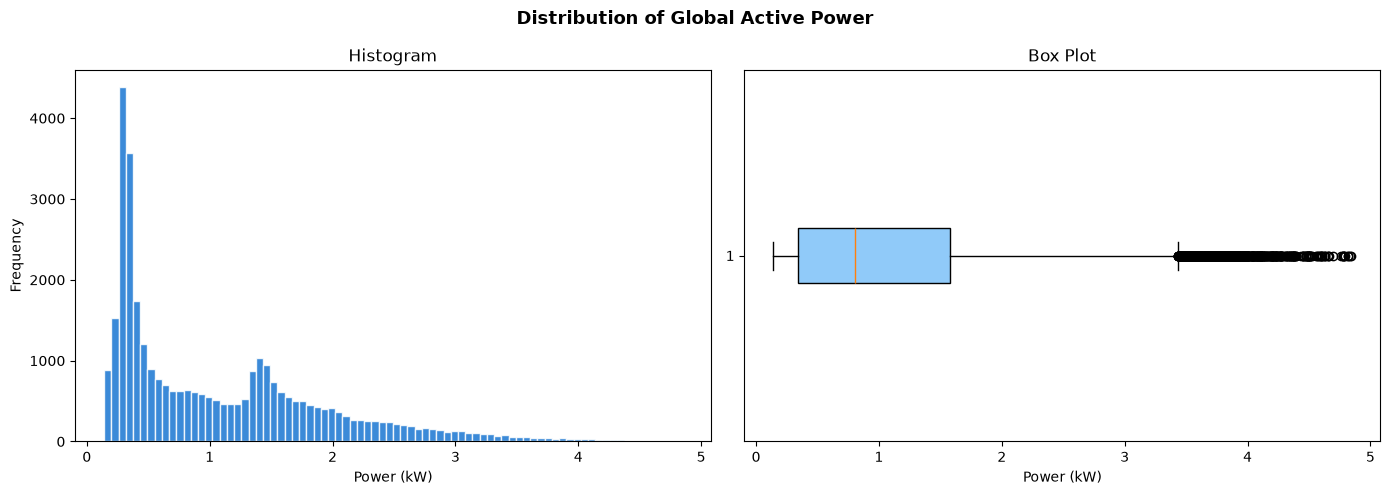

Mean   : 1.083 kW
Median : 0.802 kW
Std    : 0.871 kW
Skew   : 1.134


In [58]:
# 3.6 Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of Global Active Power", fontsize=13, fontweight="bold")

axes[0].hist(df_hourly["Global_active_power"], bins=80, color="#1976D2",
             edgecolor="white", alpha=0.85)
axes[0].set_title("Histogram")
axes[0].set_xlabel("Power (kW)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(df_hourly["Global_active_power"].dropna(), vert=False,
                patch_artist=True,
                boxprops=dict(facecolor="#90CAF9"))
axes[1].set_title("Box Plot")
axes[1].set_xlabel("Power (kW)")

plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

stats = df_hourly["Global_active_power"].describe()
print(f"Mean   : {stats['mean']:.3f} kW")
print(f"Median : {df_hourly['Global_active_power'].median():.3f} kW")
print(f"Std    : {stats['std']:.3f} kW")
print(f"Skew   : {df_hourly['Global_active_power'].skew():.3f}")

# Step 4: Feature Engineering


In [59]:
# 4.1 Lag features
df_feat = df_hourly.copy()
target  = "Global_active_power"

lag_hours = [1, 2, 3, 6, 12, 24, 48, 168]   # 168 = 1 week ago
for lag in lag_hours:
    df_feat[f"lag_{lag}h"] = df_feat[target].shift(lag)

print(f"Added {len(lag_hours)} lag features")

Added 8 lag features


In [60]:
# 4.2 Rolling window statistics
windows = [3, 6, 24, 168]
for w in windows:
    df_feat[f"roll_mean_{w}h"] = df_feat[target].shift(1).rolling(w).mean()
    df_feat[f"roll_std_{w}h"]  = df_feat[target].shift(1).rolling(w).std()

print(f"Added {len(windows)*2} rolling features (mean + std for each window)")

Added 8 rolling features (mean + std for each window)


In [61]:
# 4.3 Cyclical encoding (sin/cos) for hour & month
# Helps the model understand 23:00 and 00:00 are adjacent
df_feat["hour_sin"]  = np.sin(2 * np.pi * df_feat["hour"]  / 24)
df_feat["hour_cos"]  = np.cos(2 * np.pi * df_feat["hour"]  / 24)
df_feat["month_sin"] = np.sin(2 * np.pi * df_feat["month"] / 12)
df_feat["month_cos"] = np.cos(2 * np.pi * df_feat["month"] / 12)

print("Added cyclical (sin/cos) encodings for hour and month")

Added cyclical (sin/cos) encodings for hour and month


In [62]:
# 4.4 Drop NaN rows created by lag/rolling
df_feat.dropna(inplace=True)

# Final feature list
FEATURES = [c for c in df_feat.columns if c != target]
TARGET   = target

print(f"Feature engineering complete!")
print(f"   Total features : {len(FEATURES)}")
print(f"   Dataset rows   : {len(df_feat):,}  (after dropping NaN from lags)")
print()
print("Feature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i:2d}. {f}")

Feature engineering complete!
   Total features : 35
   Dataset rows   : 34,008  (after dropping NaN from lags)

Feature list:
    1. Global_reactive_power
    2. Voltage
    3. Global_intensity
    4. Sub_metering_1
    5. Sub_metering_2
    6. Sub_metering_3
    7. hour
    8. day_of_week
    9. day_of_month
   10. month
   11. quarter
   12. year
   13. week_of_year
   14. is_weekend
   15. season
   16. lag_1h
   17. lag_2h
   18. lag_3h
   19. lag_6h
   20. lag_12h
   21. lag_24h
   22. lag_48h
   23. lag_168h
   24. roll_mean_3h
   25. roll_std_3h
   26. roll_mean_6h
   27. roll_std_6h
   28. roll_mean_24h
   29. roll_std_24h
   30. roll_mean_168h
   31. roll_std_168h
   32. hour_sin
   33. hour_cos
   34. month_sin
   35. month_cos


# Step 5: Build XGBoost Model


In [63]:
# 5.1 Chronological train / test split (80% / 20%)
split_idx = int(len(df_feat) * 0.80)

train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train/Test split complete (chronological)")
print(f"   Train: {len(train):,} rows  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"   Test : {len(test):,} rows  ({test.index.min().date()}  -> {test.index.max().date()})")
print(f"   Features: {len(FEATURES)}")

Train/Test split complete (chronological)
   Train: 27,206 rows  (2006-12-23 -> 2010-02-06)
   Test : 6,802 rows  (2010-02-06  -> 2010-11-26)
   Features: 35


In [64]:
# 5.2 Train XGBoost model
print("Training XGBoost model...")

model = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,
    eval_metric           = "rmse"
)

model.fit(
    X_train, y_train,
    eval_set  = [(X_train, y_train), (X_test, y_test)],
    verbose   = 200
)

print("\nModel training complete!")
print(f"   Best iteration: {model.best_iteration}")

Training XGBoost model...
[0]	validation_0-rmse:0.86690	validation_1-rmse:0.71179
[200]	validation_0-rmse:0.03089	validation_1-rmse:0.04068
[400]	validation_0-rmse:0.02150	validation_1-rmse:0.03612
[600]	validation_0-rmse:0.01771	validation_1-rmse:0.03498
[800]	validation_0-rmse:0.01532	validation_1-rmse:0.03449
[999]	validation_0-rmse:0.01354	validation_1-rmse:0.03426

Model training complete!
   Best iteration: 999


# Step 6: Model Evaluation


In [65]:
# 6.1 Predict & compute metrics
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    mask   = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

metrics = {
    "RMSE" : (np.sqrt(mean_squared_error(y_train, y_pred_train)),
              np.sqrt(mean_squared_error(y_test,  y_pred_test))),
    "MAE"  : (mean_absolute_error(y_train, y_pred_train),
              mean_absolute_error(y_test,  y_pred_test)),
    "R2"   : (r2_score(y_train, y_pred_train),
              r2_score(y_test,  y_pred_test)),
    "MAPE" : (mape(y_train, y_pred_train),
              mape(y_test,  y_pred_test)),
}

print("=" * 50)
print(f"{'Metric':<10} {'Train':>15} {'Test':>15}")
print("=" * 50)
for name, (tr, te) in metrics.items():
    unit = "%" if name == "MAPE" else ("" if name == "R2" else " kW")
    print(f"{name:<10} {tr:>14.4f}{unit}  {te:>14.4f}{unit}")
print("=" * 50)
print(f"\nModel Accuracy   : {100 - metrics['MAPE'][1]:.2f}%  (100 - MAPE)")
print(f"Variance explained: {metrics['R2'][1]*100:.2f}%  (R2)")

Metric               Train            Test
RMSE               0.0135 kW          0.0343 kW
MAE                0.0096 kW          0.0192 kW
R2                 0.9998          0.9978
MAPE               1.3684%          2.1906%

Model Accuracy   : 97.81%  (100 - MAPE)
Variance explained: 99.78%  (R2)


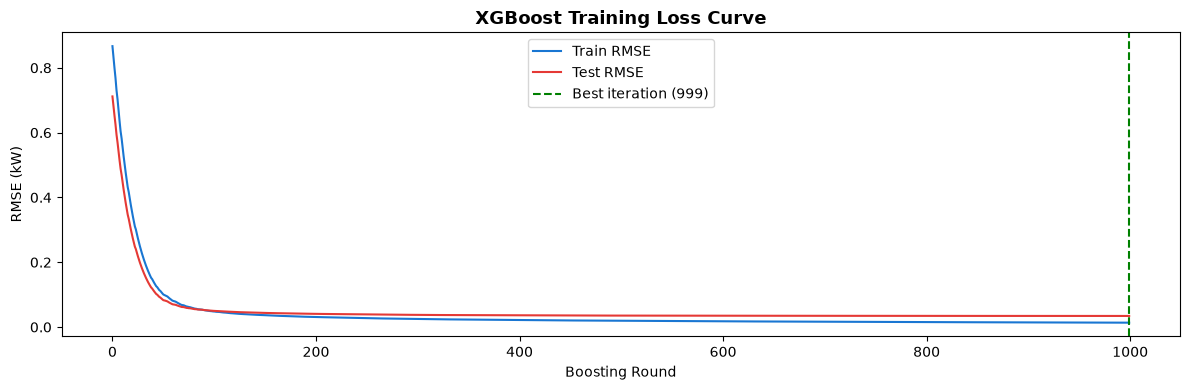

In [66]:
# 6.2 Training loss curve
results = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results["validation_0"]["rmse"], label="Train RMSE", color="#1976D2", lw=1.5)
ax.plot(results["validation_1"]["rmse"], label="Test RMSE",  color="#E53935", lw=1.5)
ax.axvline(model.best_iteration, color="green", lw=1.5,
           linestyle="--", label=f"Best iteration ({model.best_iteration})")
ax.set_title("XGBoost Training Loss Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (kW)")
ax.legend()
plt.tight_layout()
plt.savefig("eval_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

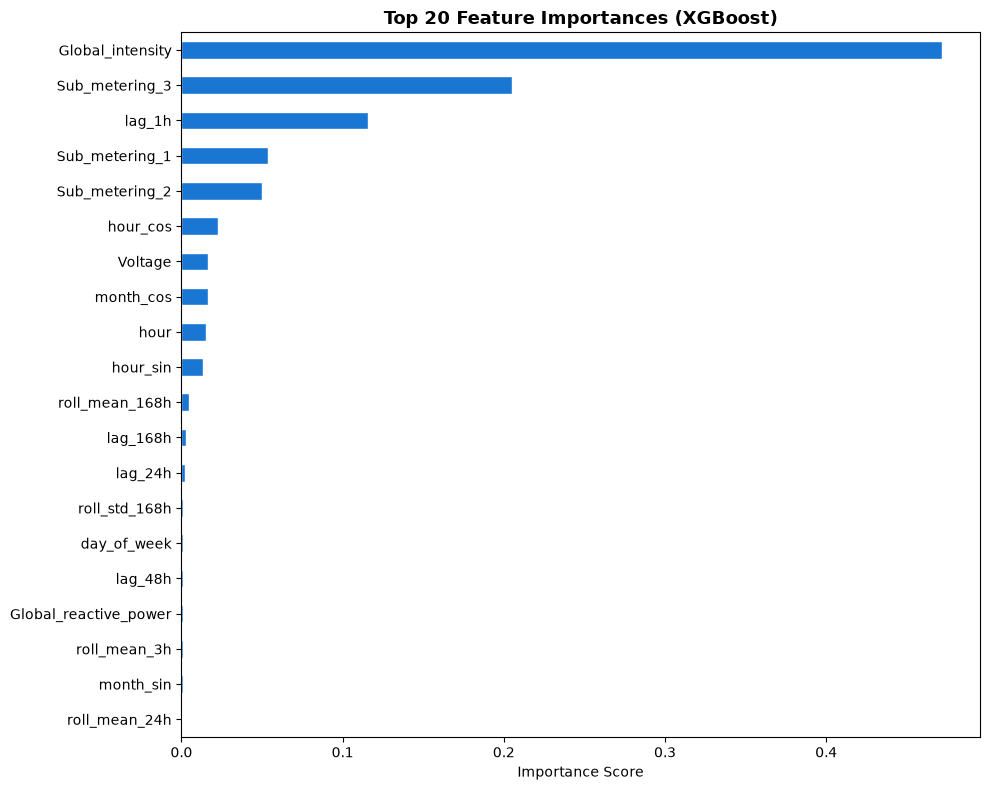

Lag features and rolling means dominate - confirms strong autocorrelation.


In [67]:
# 6.3 Feature importance
importance = pd.Series(model.feature_importances_, index=FEATURES)
top20      = importance.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind="barh", ax=ax, color="#1976D2", edgecolor="white")
ax.set_title("Top 20 Feature Importances (XGBoost)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("eval_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Lag features and rolling means dominate - confirms strong autocorrelation.")

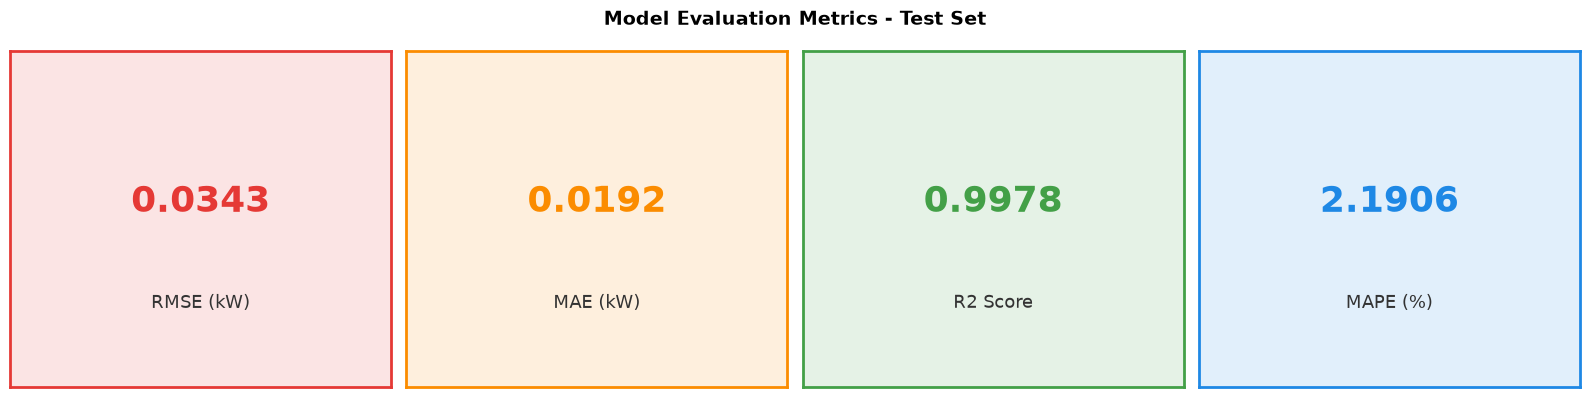

In [68]:
# 6.4 Metrics summary card
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Model Evaluation Metrics - Test Set", fontsize=14, fontweight="bold")

metric_names  = ["RMSE (kW)", "MAE (kW)", "R2 Score", "MAPE (%)"]
metric_values = [
    metrics["RMSE"][1],
    metrics["MAE"][1],
    metrics["R2"][1],
    metrics["MAPE"][1]
]
colors = ["#E53935", "#FB8C00", "#43A047", "#1E88E5"]

for ax, name, val, col in zip(axes, metric_names, metric_values, colors):
    ax.set_facecolor(col + "22")
    ax.text(0.5, 0.55, f"{val:.4f}", ha="center", va="center",
            fontsize=26, fontweight="bold", color=col, transform=ax.transAxes)
    ax.text(0.5, 0.25, name, ha="center", va="center",
            fontsize=13, color="#333333", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("eval_metrics_card.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 7: Visualise Predictions vs Actual


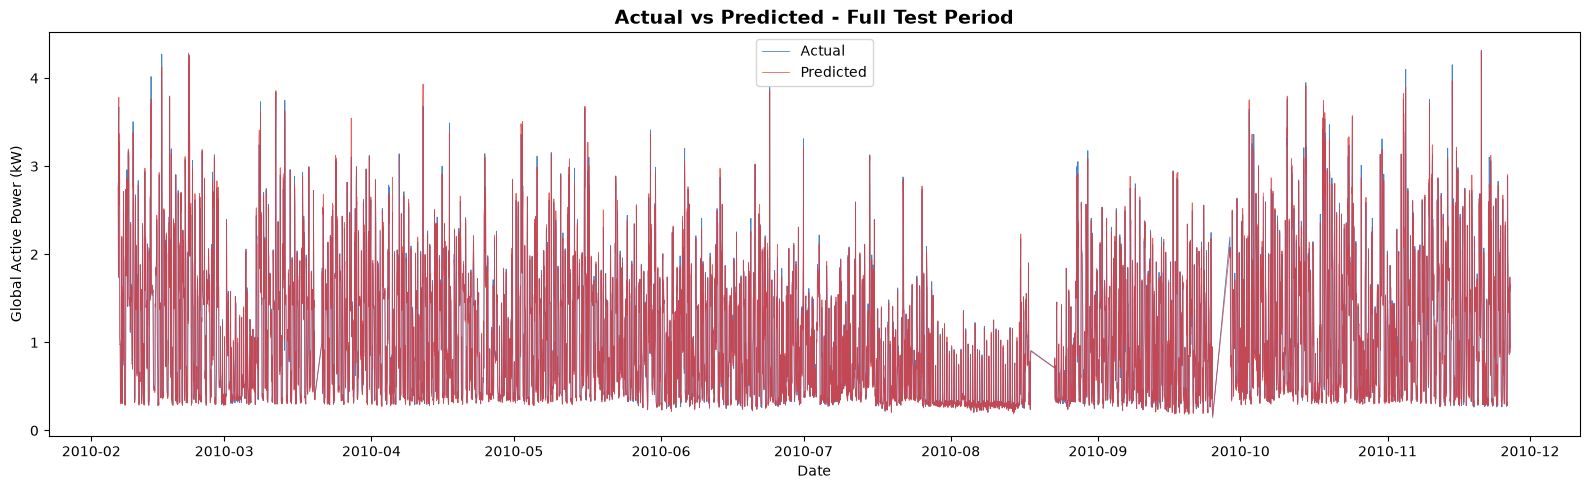

In [69]:
# 7.1 Full test period: Actual vs Predicted
results_df = pd.DataFrame({
    "Actual"   : y_test.values,
    "Predicted": y_pred_test
}, index=test.index)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(results_df["Actual"],    label="Actual",    color="#1565C0", lw=0.6, alpha=0.8)
ax.plot(results_df["Predicted"], label="Predicted", color="#E53935", lw=0.6, alpha=0.8)
ax.set_title("Actual vs Predicted - Full Test Period", fontsize=14, fontweight="bold")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("viz_full_test.png", dpi=150, bbox_inches="tight")
plt.show()

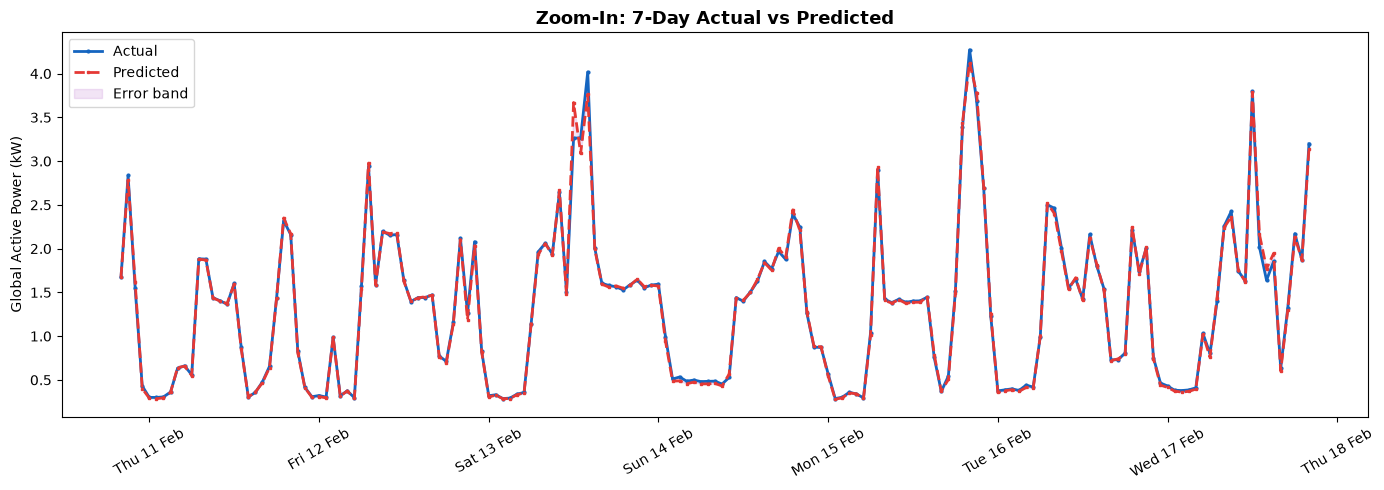

In [70]:
# 7.2 Zoom: One week of predictions
week_start = results_df.index[100]
week_end   = week_start + pd.Timedelta(days=7)
week       = results_df.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(week["Actual"],    label="Actual",    color="#1565C0", lw=2,   marker="o", markersize=2)
ax.plot(week["Predicted"], label="Predicted", color="#E53935", lw=2,
        linestyle="--",   marker="s", markersize=2)
ax.fill_between(week.index, week["Actual"], week["Predicted"],
                alpha=0.12, color="#9C27B0", label="Error band")
ax.set_title("Zoom-In: 7-Day Actual vs Predicted", fontsize=13, fontweight="bold")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("viz_week_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

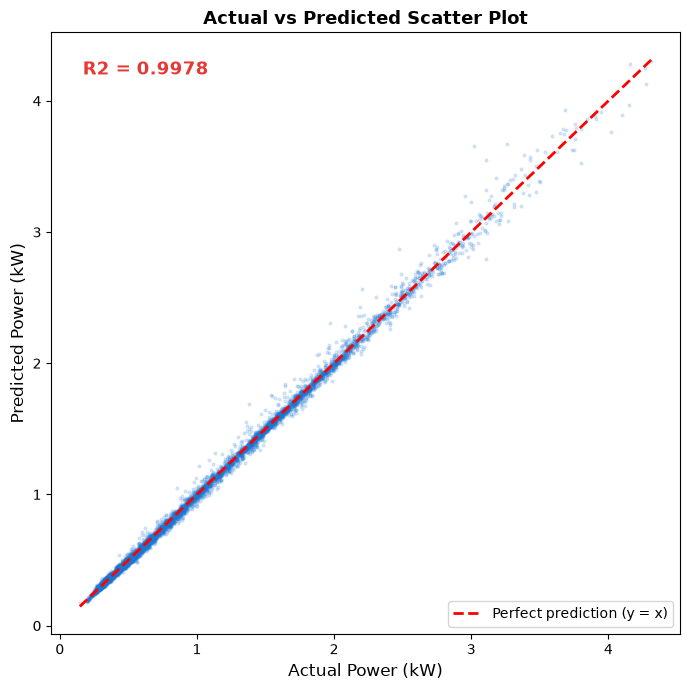

In [71]:
# 7.3 Scatter plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(results_df["Actual"], results_df["Predicted"],
           alpha=0.15, s=4, color="#1976D2")

# Perfect prediction line
lims = [results_df.min().min(), results_df.max().max()]
ax.plot(lims, lims, "r--", lw=2, label="Perfect prediction (y = x)")

ax.set_xlabel("Actual Power (kW)",    fontsize=12)
ax.set_ylabel("Predicted Power (kW)", fontsize=12)
ax.set_title("Actual vs Predicted Scatter Plot", fontsize=13, fontweight="bold")
ax.legend()

# Add R2 annotation
r2 = metrics["R2"][1]
ax.text(0.05, 0.93, f"R2 = {r2:.4f}", transform=ax.transAxes,
        fontsize=13, color="#E53935", fontweight="bold")
plt.tight_layout()
plt.savefig("viz_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

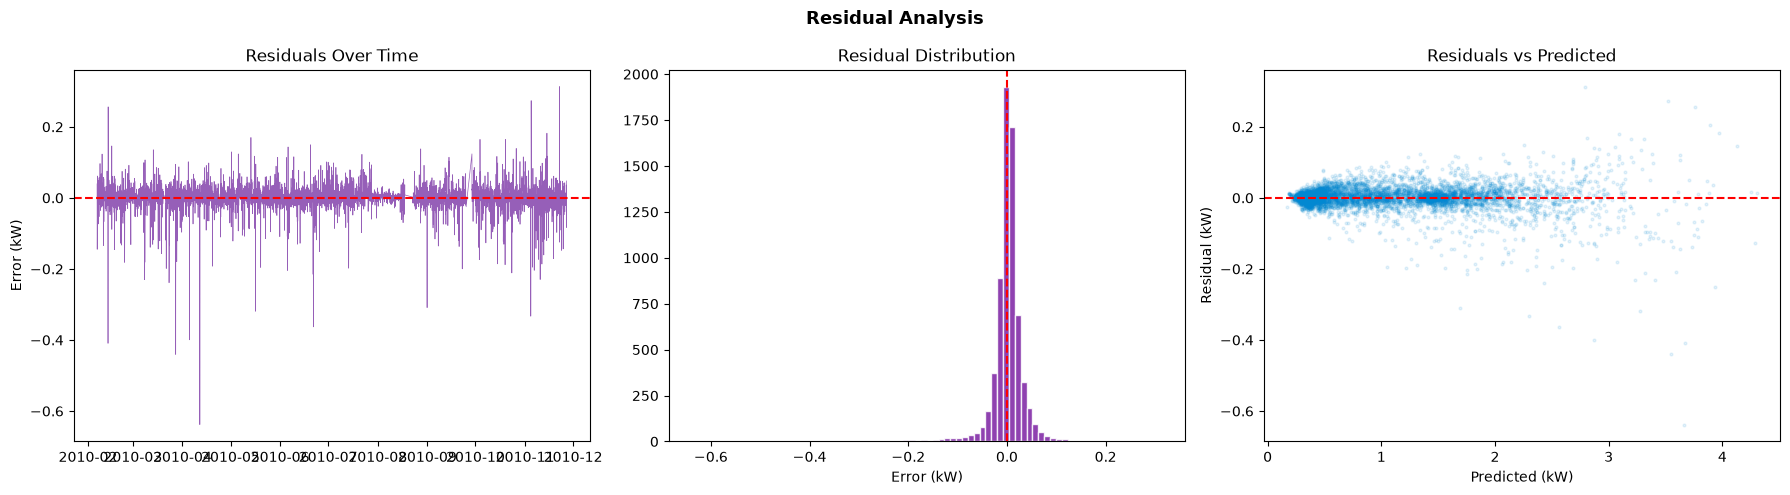

Mean residual : 0.0013 kW  (close to 0 = unbiased)
Residual std  : 0.0342 kW


In [72]:
# 7.4 Residual (error) analysis
residuals = results_df["Actual"] - results_df["Predicted"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Residual Analysis", fontsize=13, fontweight="bold")

# Residuals over time
axes[0].plot(residuals, color="#6A1B9A", lw=0.5, alpha=0.7)
axes[0].axhline(0, color="red", lw=1.5, linestyle="--")
axes[0].set_title("Residuals Over Time")
axes[0].set_ylabel("Error (kW)")

# Histogram
axes[1].hist(residuals, bins=80, color="#7B1FA2", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", lw=1.5, linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error (kW)")

# Residuals vs Predicted
axes[2].scatter(results_df["Predicted"], residuals,
                alpha=0.1, s=4, color="#0288D1")
axes[2].axhline(0, color="red", lw=1.5, linestyle="--")
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted (kW)")
axes[2].set_ylabel("Residual (kW)")

plt.tight_layout()
plt.savefig("viz_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean residual : {residuals.mean():.4f} kW  (close to 0 = unbiased)")
print(f"Residual std  : {residuals.std():.4f} kW")

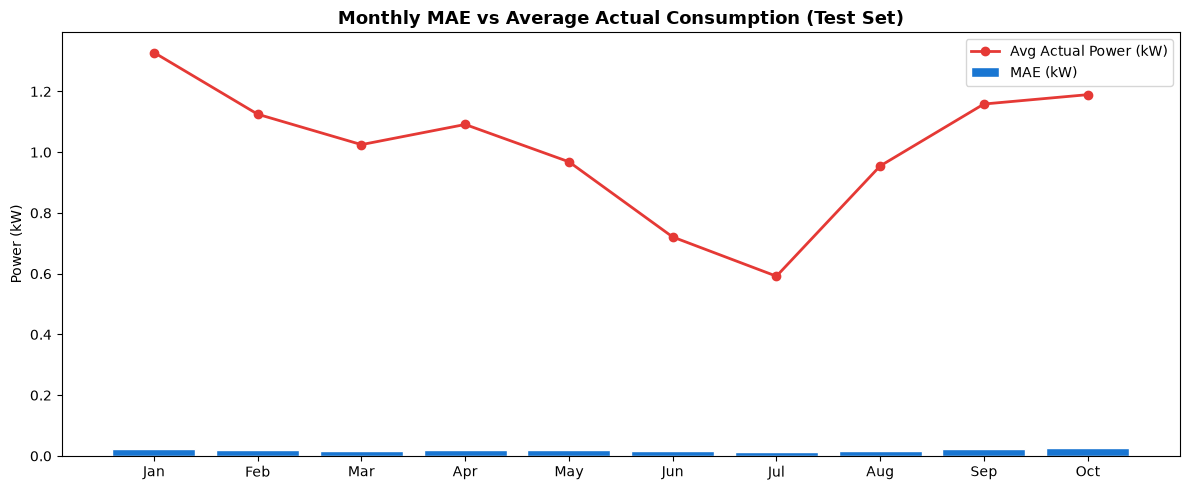

In [73]:
# 7.5 Monthly performance breakdown
results_df["month"] = results_df.index.month
results_df["error"] = np.abs(results_df["Actual"] - results_df["Predicted"])

monthly = results_df.groupby("month").agg(
    MAE    = ("error",  "mean"),
    Actual = ("Actual", "mean")
).round(4)
monthly.index = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"][:len(monthly)]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(monthly))
ax.bar(x, monthly["MAE"], color="#1976D2", edgecolor="white", label="MAE (kW)")
ax.plot(x, monthly["Actual"], color="#E53935", marker="o",
        lw=2, label="Avg Actual Power (kW)")
ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_title("Monthly MAE vs Average Actual Consumption (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Power (kW)")
ax.legend()
plt.tight_layout()
plt.savefig("viz_monthly_perf.png", dpi=150, bbox_inches="tight")
plt.show()